# Security Data — k-Nearest Neighbours (kNN)

## Dataset
Data sourced from `security_data_10000.csv` (synthetic data generated from original class dataset).

| Column | Description |
|--------|-------------|
| Sector | Industry sector of the company |
| CEO_Gender | Gender of the CEO (Male/Female) |
| Size | Company size (Large, Medium, Small) |
| Security_Invest | Security investment amount |
| Security_Breach_Att | Number of security breach attempts |
| Succ_Sec_Breaches | Number of successful security breaches |
| Sec_Rating | Overall security rating (High/Medium/Low) |
| CEO_Sec_Exp | CEO's level of security experience (High/Medium/Low) |
| LOT_in_Business | Length of time in business (years) |
| Stock_Market | Whether the company is listed on the stock market (Yes/No) |

---

## What is kNN?
kNN predicts based on the **k closest training examples** in feature space.
- **Low k** (e.g. k=1) — very sensitive to noise, high variance
- **High k** (e.g. k=15) — smoother decision boundary, lower variance but may underfit
- **Feature scaling is required** — kNN uses distance, so unscaled features will dominate

## This Notebook Covers
| Section | Task | Algorithm |
|---------|------|-----------|
| Part A | Predict Stock Market (Yes/No) | kNN Classifier (k=1,5,10,15) |
| Part B | Predict Successful Breaches | kNN Regressor (k=1,5,10,15) |

---

## Data Analysis Plan
1. **Load Data** — Read CSV
2. **Train-Test Split** — Split before feature engineering
3. **Create Label** — Binary (CEO Gender) or continuous (Succ_Sec_Breaches)
4. **Drop Target** — Remove target column from features
5. **Impute** — Handle missing values (fit on train only)
6. **Encode** — One-hot encode categorical features
7. **Scale** — StandardScaler (critical for kNN — distance-based algorithm)
8. **Fit & Predict** — Run kNN at k=1, 5, 10, 15
9. **Evaluate** — Confusion matrix + F1 (classifier) or R²/MSE (regressor)

# Part A — kNN Classifier
## Step 1 — Load Dataset

In [ ]:
#LOAD THE DATASET


import pandas as pd

file_path = "https://raw.githubusercontent.com/eddiejaques/ml-code-samples/refs/heads/main/Security%20Breaches%20Dataset/security_data.csv"

security_df = pd.read_csv(file_path)

security_df.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
0,Hospitality,Male,Large,186,80,38,High,High,11,No
1,Hospitality,Female,Large,229,72,42,Medium,Medium,21,Yes
2,Hospitality,Male,Small,108,78,35,High,Medium,15,Yes
3,Hospitality,Male,Large,210,70,35,Medium,Low,14,No
4,Banking,Male,Small,34,19,3,Low,High,3,No


## Step 2 — Train-Test Split
Split performed **before** any feature engineering to prevent data leakage.

In [339]:
from sklearn.model_selection import train_test_split
security_df_train, security_df_test = train_test_split(security_df, test_size=0.2, random_state=42)


## Step 3 — Create Binary Label
`True` = Male CEO, `False` = Female CEO.

In [340]:
security_df_train_label = (security_df_train["Stock_Market"] == 'Yes')

security_df_test_label = (security_df_test["Stock_Market"] =='Yes')

## Step 4 — Drop Target Column
`Stock_Market` removed from features — it is the target variable.

In [341]:
security_df_train = security_df_train.drop(columns=["Stock_Market"])
security_df_test = security_df_test.drop(columns=["Stock_Market"])

In [342]:
print ("Training data shape:", security_df_train.shape)
print ("Testing data shape:", security_df_test.shape)

security_df_train.head()


Training data shape: (8000, 9)
Testing data shape: (2000, 9)


,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business
9254,Hospitality,Male,Large,123,78,26,High,Medium,16
1561,Hospitality,Male,Medium,419,250,90,Low,High,15
1670,Banking,Male,Small,28,8,0,Medium,High,15
6087,Health Care,Male,Large,86,49,26,High,Medium,18
6669,Health Care,Male,Medium,125,16,5,Medium,High,10


In [343]:
cat_cols = ['Sector', 'CEO_Gender']
ordered_cat_cols = [ 'Size', 'Sec_Rating', 'CEO_Sec_Exp']
numerical_cols = ["Security_Invest", "Security_Breach_Att", "Succ_Sec_Breaches", "LOT_in_Business"]

## Step 5 — Impute Numeric Features
Fit imputer on train only, transform both. Preserves column names and index for later concatenation.

In [344]:
import numpy as np  
import pandas as pd
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy="median")

security_df_train_num = security_df_train.select_dtypes(include=[np.number])
security_df_test_num = security_df_test.select_dtypes(include=[np.number])

imputer.fit(security_df_train_num)

security_df_train_tf = imputer.transform(security_df_train_num)
security_df_test_tf = imputer.transform(security_df_test_num)

security_df_train_tf = pd.DataFrame(security_df_train_tf, 
                                     columns=security_df_train_num.columns,
                                     index=security_df_train_num.index)

security_df_test_tf  = pd.DataFrame(security_df_test_tf, 
                                     columns=security_df_test_num.columns,
                                     index=security_df_test_num.index)

print ("Training data shape:", security_df_train.shape)
print ("Testing data shape:", security_df_test.shape)



Training data shape: (8000, 9)
Testing data shape: (2000, 9)


## Step 6 — Encode Categorical Features
One-hot encode all categorical columns. `Stock_Market` is excluded as it is the target.

In [345]:


security_df_train_cat = pd.get_dummies(security_df_train[cat_cols], dtype=int)
security_df_test_cat  = pd.get_dummies(security_df_test[cat_cols],  dtype=int)

security_df_test_cat.head()

security_df_train_final = pd.concat([security_df_train_tf, security_df_train_cat], axis=1)
security_df_test_final  = pd.concat([security_df_test_tf,  security_df_test_cat],  axis=1)

print('Final train shape:', security_df_train_final.shape)
print('Final test shape: ', security_df_test_final.shape)



security_df_train_final.head()

Final train shape: (8000, 9)
Final test shape:  (2000, 9)


,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business,Sector_Banking,Sector_Health Care,Sector_Hospitality,CEO_Gender_Female,CEO_Gender_Male
9254,123.0,78.0,26.0,16.0,0,0,1,0,1
1561,419.0,250.0,90.0,15.0,0,0,1,0,1
1670,28.0,8.0,0.0,15.0,1,0,0,0,1
6087,86.0,49.0,26.0,18.0,0,1,0,0,1
6669,125.0,16.0,5.0,10.0,0,1,0,0,1


In [346]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_categories = [
    ['Small', 'Medium', 'Large'],       # Size
    ['Low', 'Medium', 'High'],          # Sec_Rating
    ['Low', 'Medium', 'High'],          # CEO_Sec_Exp
]

ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)

train_ordinal = ordinal_encoder.fit_transform(security_df_train[ordered_cat_cols])
test_ordinal = ordinal_encoder.transform(security_df_test[ordered_cat_cols])

train_ordinal_df = pd.DataFrame(train_ordinal, columns=ordered_cat_cols, index=security_df_train.index)
test_ordinal_df = pd.DataFrame(test_ordinal, columns=ordered_cat_cols, index=security_df_test.index)

# Replace original ordinal columns with encoded versions
security_df_train_final = pd.concat([security_df_train_final, train_ordinal_df], axis=1)
security_df_test_final = pd.concat([security_df_test_final, test_ordinal_df], axis=1)

print('Final train shape:', security_df_train_final.shape)
print('Final test shape: ', security_df_test_final.shape)

security_df_train_final.head()

Final train shape: (8000, 12)
Final test shape:  (2000, 12)


,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business,Sector_Banking,Sector_Health Care,Sector_Hospitality,CEO_Gender_Female,CEO_Gender_Male,Size,Sec_Rating,CEO_Sec_Exp
9254,123.0,78.0,26.0,16.0,0,0,1,0,1,2.0,2.0,1.0
1561,419.0,250.0,90.0,15.0,0,0,1,0,1,1.0,0.0,2.0
1670,28.0,8.0,0.0,15.0,1,0,0,0,1,0.0,1.0,2.0
6087,86.0,49.0,26.0,18.0,0,1,0,0,1,2.0,2.0,1.0
6669,125.0,16.0,5.0,10.0,0,1,0,0,1,1.0,1.0,2.0


## Step 7 — Scale Features
kNN uses Euclidean distance — scaling is **mandatory** so no single feature dominates. Fit scaler on train only.

In [347]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

security_df_train_scaled = scaler.fit_transform(security_df_train_final[numerical_cols])
security_df_test_scaled = scaler.transform(security_df_test_final[numerical_cols])

## After scaling, we need to convert the scaled arrays back to DataFrames and concatenate them with the categorical columns

security_df_train_final = pd.concat([security_df_train_final.drop(columns=numerical_cols), pd.DataFrame(security_df_train_scaled, columns=numerical_cols, index=security_df_train_final.index)], axis=1)
security_df_test_final = pd.concat([security_df_test_final.drop(columns=numerical_cols), pd.DataFrame(security_df_test_scaled, columns=numerical_cols, index=security_df_test_final.index)], axis=1)

print('Final train shape:', security_df_train_final.shape)
print('Final test shape: ', security_df_test_final.shape)

security_df_train_final.head()


Final train shape: (8000, 12)
Final test shape:  (2000, 12)


,Sector_Banking,Sector_Health Care,Sector_Hospitality,CEO_Gender_Female,CEO_Gender_Male,Size,Sec_Rating,CEO_Sec_Exp,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business
9254,0,0,1,0,1,2.0,2.0,1.0,0.508713,0.239649,0.028895,0.414143
1561,0,0,1,0,1,1.0,0.0,2.0,4.093372,2.569869,1.789515,0.275058
1670,1,0,0,0,1,0.0,1.0,2.0,-0.641769,-0.708697,-0.686356,0.275058
6087,0,1,0,0,1,2.0,2.0,1.0,0.060630,-0.153237,0.028895,0.692313
6669,0,1,0,0,1,1.0,1.0,2.0,0.532933,-0.600315,-0.548808,-0.420367


## Step 8 — Fit kNN Classifier & Evaluate (k=1,5,10,15)
Higher k = smoother boundary. Evaluate with confusion matrix and classification report.

In [348]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf_1 = KNeighborsClassifier(n_neighbors=1)

knn_clf_5 = KNeighborsClassifier(n_neighbors=5)

knn_clf_10 = KNeighborsClassifier(n_neighbors=10)

knn_clf_15 = KNeighborsClassifier(n_neighbors=15)


knn_clf_1.fit(security_df_train_final, security_df_train_label)

knn_clf_5.fit(security_df_train_final, security_df_train_label)

knn_clf_10.fit(security_df_train_final, security_df_train_label)

knn_clf_15.fit(security_df_train_final, security_df_train_label)


security_df_test_pred_1 = knn_clf_1.predict(security_df_test_final)
security_df_train_pred_1 = knn_clf_1.predict(security_df_train_final)

security_df_test_pred_5 = knn_clf_5.predict(security_df_test_final)
security_df_train_pred_5 = knn_clf_5.predict(security_df_train_final)

security_df_test_pred_10 = knn_clf_10.predict(security_df_test_final)
security_df_train_pred_10 = knn_clf_10.predict(security_df_train_final)

security_df_test_pred_15 = knn_clf_15.predict(security_df_test_final)
security_df_train_pred_15 = knn_clf_15.predict(security_df_train_final)


from sklearn.metrics import confusion_matrix, classification_report

print("KNN with k=1")
print(confusion_matrix(security_df_test_label, security_df_test_pred_1))
print(classification_report(security_df_test_label, security_df_test_pred_1))


print("KNN with k=5")
print(confusion_matrix(security_df_test_label, security_df_test_pred_5))

print(classification_report(security_df_test_label, security_df_test_pred_5))

print("KNN with k=10")
print(confusion_matrix(security_df_test_label, security_df_test_pred_10))

print(classification_report(security_df_test_label, security_df_test_pred_10))

print("KNN with k=15")
print(confusion_matrix(security_df_test_label, security_df_test_pred_15))
print(classification_report(security_df_test_label, security_df_test_pred_15))




KNN with k=1
[[327 419]
 [399 855]]
              precision    recall  f1-score   support

       False       0.45      0.44      0.44       746
        True       0.67      0.68      0.68      1254

    accuracy                           0.59      2000
   macro avg       0.56      0.56      0.56      2000
weighted avg       0.59      0.59      0.59      2000

KNN with k=5
[[320 426]
 [317 937]]
              precision    recall  f1-score   support

       False       0.50      0.43      0.46       746
        True       0.69      0.75      0.72      1254

    accuracy                           0.63      2000
   macro avg       0.59      0.59      0.59      2000
weighted avg       0.62      0.63      0.62      2000

KNN with k=10
[[368 378]
 [348 906]]
              precision    recall  f1-score   support

       False       0.51      0.49      0.50       746
        True       0.71      0.72      0.71      1254

    accuracy                           0.64      2000
   macro avg       

k=15 is the best

## Step 9 — Decision Boundary Plot (PCA 2D Projection)
Since we have 12 features, PCA reduces them to 2D so we can visualise the KNN decision regions. Each coloured region shows where KNN (k=15) would predict **Stock Market = Yes or No**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

# Reduce to 2D with PCA
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(security_df_train_final)
X_test_2d  = pca.transform(security_df_test_final)

# Fit KNN classifier on 2D PCA space (k=15, best performer)
knn_2d = KNeighborsClassifier(n_neighbors=15)
knn_2d.fit(X_train_2d, security_df_train_label)

# Build mesh grid over PCA space
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlGn")

colors = {True: "green", False: "red"}
labels = {True: "Stock Market = Yes", False: "Stock Market = No"}

for cls in [True, False]:
    mask = security_df_test_label.values == cls
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
               c=colors[cls], label=labels[cls], s=10, alpha=0.5, edgecolors="none")

ax.set_title("KNN Decision Boundary (k=15) — PCA 2D Projection", fontsize=13, fontweight="bold")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%} of total variance captured in 2D")

## Step 8 - Visualise

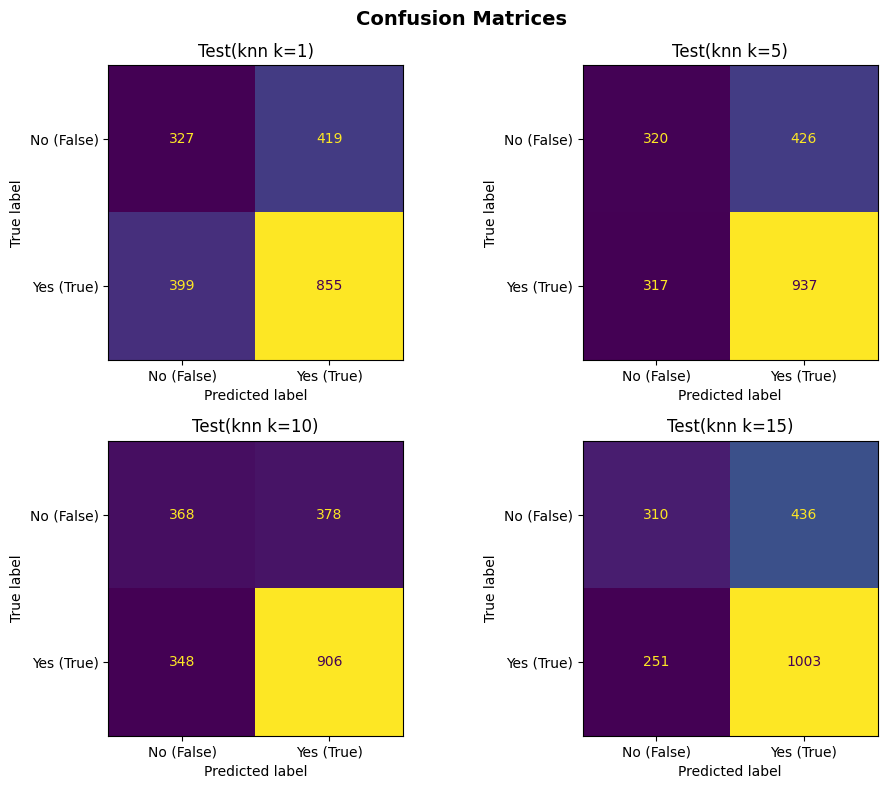

In [349]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")

datasets = [
    (security_df_test_label,  security_df_test_pred_1,  "Test(knn k=1)"),
    (security_df_test_label,  security_df_test_pred_5,  "Test(knn k=5)"),
    (security_df_test_label,  security_df_test_pred_10,  "Test(knn k=10)"),
    (security_df_test_label,  security_df_test_pred_15,  "Test(knn k=15)")
]

for ax, (y_true, y_pred, title) in zip(axes.flat, datasets):
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["No (False)", "Yes (True)"],
        colorbar=False,
        ax=ax,
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Part B — kNN Regressor
**Objective:** Predict `Succ_Sec_Breaches` (a continuous value) using all features.

kNN Regressor predicts by averaging the target values of the k nearest neighbours.

## Step 1 — Load Dataset

In [350]:
#LOAD THE DATASET


import pandas as pd

security_df = pd.read_csv(file_path)

security_df.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
0,Hospitality,Male,Large,186,80,38,High,High,11,No
1,Hospitality,Female,Large,229,72,42,Medium,Medium,21,Yes
2,Hospitality,Male,Small,108,78,35,High,Medium,15,Yes
3,Hospitality,Male,Large,210,70,35,Medium,Low,14,No
4,Banking,Male,Small,34,19,3,Low,High,3,No


## Step 2 — Train-Test Split

In [351]:
from sklearn.model_selection import train_test_split
security_df_train, security_df_test = train_test_split(security_df, test_size=0.2, random_state=42)


## Step 3 — Create Continuous Label
`Succ_Sec_Breaches` is a numeric count — used directly as the regression target.

In [352]:
security_df_train_label = security_df_train["Succ_Sec_Breaches"]

security_df_test_label = security_df_test["Succ_Sec_Breaches"]

cat_cols = ['Sector', 'CEO_Gender','Stock_Market']

ordered_cat_cols = [ 'Size', 'Sec_Rating', 'CEO_Sec_Exp']

numerical_cols = ["Security_Invest", "Security_Breach_Att","LOT_in_Business"]

## Step 4 — Drop Target Column

In [353]:
security_df_train = security_df_train.drop(columns=["Succ_Sec_Breaches"])
security_df_test = security_df_test.drop(columns=["Succ_Sec_Breaches"])

## Step 5 — Impute, Encode & Scale

In [354]:
import numpy as np  
import pandas as pd
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy="median")

security_df_train_num = security_df_train.select_dtypes(include=[np.number])
security_df_test_num = security_df_test.select_dtypes(include=[np.number])

imputer.fit(security_df_train_num)

security_df_train_tf = imputer.transform(security_df_train_num)
security_df_test_tf = imputer.transform(security_df_test_num)

security_df_train_tf = pd.DataFrame(security_df_train_tf, 
                                     columns=security_df_train_num.columns,
                                     index=security_df_train_num.index)

security_df_test_tf  = pd.DataFrame(security_df_test_tf, 
                                     columns=security_df_test_num.columns,
                                     index=security_df_test_num.index)



In [355]:
print("Categorical columns:", cat_cols)
print("Numerical columns:", numerical_cols)


security_df_train_cat = pd.get_dummies(security_df_train[cat_cols], dtype=int)
security_df_test_cat  = pd.get_dummies(security_df_test[cat_cols],  dtype=int)

security_df_test_cat.head()

security_df_train_final = pd.concat([security_df_train_tf, security_df_train_cat], axis=1)
security_df_test_final  = pd.concat([security_df_test_tf,  security_df_test_cat],  axis=1)

print('Final train shape:', security_df_train_final.shape)
print('Final test shape: ', security_df_test_final.shape)

Categorical columns: ['Sector', 'CEO_Gender', 'Stock_Market']
Numerical columns: ['Security_Invest', 'Security_Breach_Att', 'LOT_in_Business']
Final train shape: (8000, 10)
Final test shape:  (2000, 10)


In [356]:
security_df_train_final.head()

,Security_Invest,Security_Breach_Att,LOT_in_Business,Sector_Banking,Sector_Health Care,Sector_Hospitality,CEO_Gender_Female,CEO_Gender_Male,Stock_Market_No,Stock_Market_Yes
9254,123.0,78.0,16.0,0,0,1,0,1,0,1
1561,419.0,250.0,15.0,0,0,1,0,1,0,1
1670,28.0,8.0,15.0,1,0,0,0,1,0,1
6087,86.0,49.0,18.0,0,1,0,0,1,1,0
6669,125.0,16.0,10.0,0,1,0,0,1,0,1


In [357]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_categories = [
    ['Small', 'Medium', 'Large'],       # Size
    ['Low', 'Medium', 'High'],          # Sec_Rating
    ['Low', 'Medium', 'High'],          # CEO_Sec_Exp
]

ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)

train_ordinal = ordinal_encoder.fit_transform(security_df_train[ordered_cat_cols])
test_ordinal = ordinal_encoder.transform(security_df_test[ordered_cat_cols])

train_ordinal_df = pd.DataFrame(train_ordinal, columns=ordered_cat_cols, index=security_df_train.index)
test_ordinal_df = pd.DataFrame(test_ordinal, columns=ordered_cat_cols, index=security_df_test.index)

# Replace original ordinal columns with encoded versions
security_df_train_final = pd.concat([security_df_train_final, train_ordinal_df], axis=1)
security_df_test_final = pd.concat([security_df_test_final, test_ordinal_df], axis=1)

print('Final train shape:', security_df_train_final.shape)
print('Final test shape: ', security_df_test_final.shape)

security_df_train_final.head()

Final train shape: (8000, 13)
Final test shape:  (2000, 13)


,Security_Invest,Security_Breach_Att,LOT_in_Business,Sector_Banking,Sector_Health Care,Sector_Hospitality,CEO_Gender_Female,CEO_Gender_Male,Stock_Market_No,Stock_Market_Yes,Size,Sec_Rating,CEO_Sec_Exp
9254,123.0,78.0,16.0,0,0,1,0,1,0,1,2.0,2.0,1.0
1561,419.0,250.0,15.0,0,0,1,0,1,0,1,1.0,0.0,2.0
1670,28.0,8.0,15.0,1,0,0,0,1,0,1,0.0,1.0,2.0
6087,86.0,49.0,18.0,0,1,0,0,1,1,0,2.0,2.0,1.0
6669,125.0,16.0,10.0,0,1,0,0,1,0,1,1.0,1.0,2.0


In [358]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

security_df_train_scaled = scaler.fit_transform(security_df_train_final[numerical_cols])
security_df_test_scaled = scaler.transform(security_df_test_final[numerical_cols])

## After scaling, we need to convert the scaled arrays back to DataFrames and concatenate them with the categorical columns

security_df_train_final = pd.concat([security_df_train_final.drop(columns=numerical_cols), pd.DataFrame(security_df_train_scaled, columns=numerical_cols, index=security_df_train_final.index)], axis=1)
security_df_test_final = pd.concat([security_df_test_final.drop(columns=numerical_cols), pd.DataFrame(security_df_test_scaled, columns=numerical_cols, index=security_df_test_final.index)], axis=1)

security_df_train_final.head()


,Sector_Banking,Sector_Health Care,Sector_Hospitality,CEO_Gender_Female,CEO_Gender_Male,Stock_Market_No,Stock_Market_Yes,Size,Sec_Rating,CEO_Sec_Exp,Security_Invest,Security_Breach_Att,LOT_in_Business
9254,0,0,1,0,1,0,1,2.0,2.0,1.0,0.508713,0.239649,0.414143
1561,0,0,1,0,1,0,1,1.0,0.0,2.0,4.093372,2.569869,0.275058
1670,1,0,0,0,1,0,1,0.0,1.0,2.0,-0.641769,-0.708697,0.275058
6087,0,1,0,0,1,1,0,2.0,2.0,1.0,0.060630,-0.153237,0.692313
6669,0,1,0,0,1,0,1,1.0,1.0,2.0,0.532933,-0.600315,-0.420367


In [359]:
security_df_train_scaled

array([[ 5.08712744e-01,  2.39648596e-01,  4.14143129e-01],
       [ 4.09337160e+00,  2.56986891e+00,  2.75058077e-01],
       [-6.41768984e-01, -7.08696882e-01,  2.75058077e-01],
       ...,
       [ 1.22322245e+00, -1.93880766e-01, -3.11202805e-03],
       [-6.05437982e-01, -2.07428558e-01,  1.52682355e+00],
       [ 5.81374748e-01, -3.15810898e-01,  1.10956839e+00]],
      shape=(8000, 3))

## Step 6 — Fit kNN Regressor (k=1,5,10,15)
Evaluated using R² (closer to 1 = better) and MSE (closer to 0 = better).

In [360]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg_1 = KNeighborsRegressor(n_neighbors=1)

knn_reg_5 = KNeighborsRegressor(n_neighbors=5)

knn_reg_10 = KNeighborsRegressor(n_neighbors=10)

knn_reg_15 = KNeighborsRegressor(n_neighbors=15)


knn_reg_1.fit(security_df_train_final, security_df_train_label)

knn_reg_5.fit(security_df_train_final, security_df_train_label)

knn_reg_10.fit(security_df_train_final, security_df_train_label)

knn_reg_15.fit(security_df_train_final, security_df_train_label)

security_df_train_pred_1 = knn_reg_1.predict(security_df_train_final)
security_df_test_pred_1 = knn_reg_1.predict(security_df_test_final)

security_df_test_pred_5 = knn_reg_5.predict(security_df_test_final)
security_df_train_pred_5 = knn_reg_5.predict(security_df_train_final)

security_df_test_pred_10 = knn_reg_10.predict(security_df_test_final)
security_df_train_pred_10 = knn_reg_10.predict(security_df_train_final)

security_df_test_pred_15 = knn_reg_15.predict(security_df_test_final)
security_df_train_pred_15 = knn_reg_15.predict(security_df_train_final)


In [361]:
from sklearn.metrics import r2_score, mean_squared_error


print("KNN with k=1")
print("R2 Score:", r2_score(security_df_test_label, security_df_test_pred_1))
print("MSE:", mean_squared_error(security_df_test_label, security_df_test_pred_1))

print("KNN with k=5")
print("R2 Score:", r2_score(security_df_test_label, security_df_test_pred_5))
print("MSE:", mean_squared_error(security_df_test_label, security_df_test_pred_5))

print("KNN with k=10")
print("R2 Score:", r2_score(security_df_test_label, security_df_test_pred_10))
print("MSE:", mean_squared_error(security_df_test_label, security_df_test_pred_10))

print("KNN with k=15")
print("R2 Score:", r2_score(security_df_test_label, security_df_test_pred_15))
print("MSE:", mean_squared_error(security_df_test_label, security_df_test_pred_15))



KNN with k=1
R2 Score: 0.8456071368975207
MSE: 206.9565
KNN with k=5
R2 Score: 0.9111411374101706
MSE: 119.1112
KNN with k=10
R2 Score: 0.916811396244468
MSE: 111.51048000000002
KNN with k=15
R2 Score: 0.9181140744869599
MSE: 109.76429999999999


**Best result: k=10** (R²=0.928, MSE=155) — balances variance and bias well. k=1 overfits (memorises training data), while k=10 and k=15 start to underfit.